# **Import Libraries**

In [230]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# **Load Dataset**

In [231]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **Dataset Overview**

In [232]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **Exploratory Data Analysis (EDA)**

**Target Distribution**

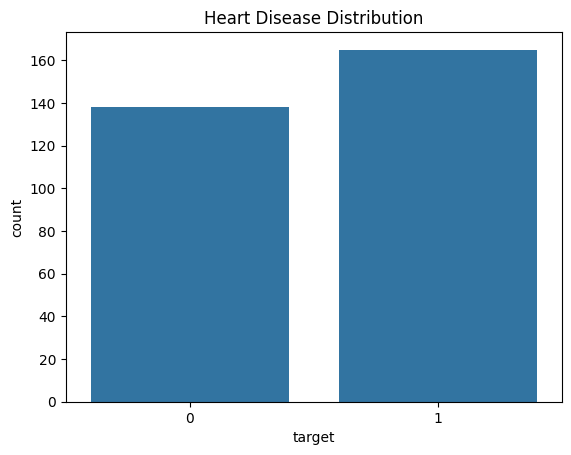

In [233]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.savefig("target_distribution.png")
plt.show()

**Age Distribution**

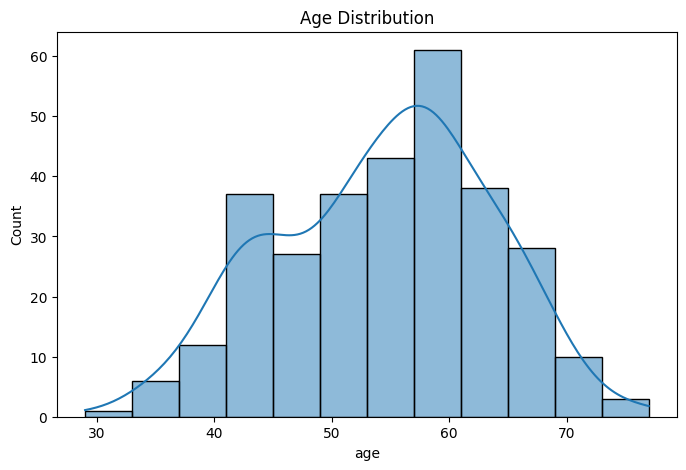

In [234]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.savefig("age_distribution.png")
plt.show()

**Gender Distribution**

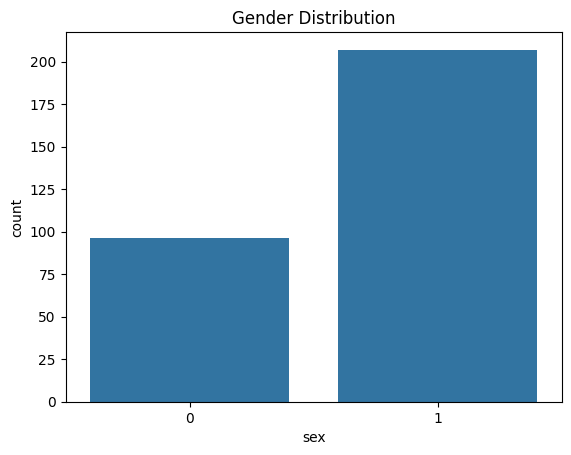

In [235]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.savefig("Gender Distribution.png")
plt.show()

**Correlation Heatmap**

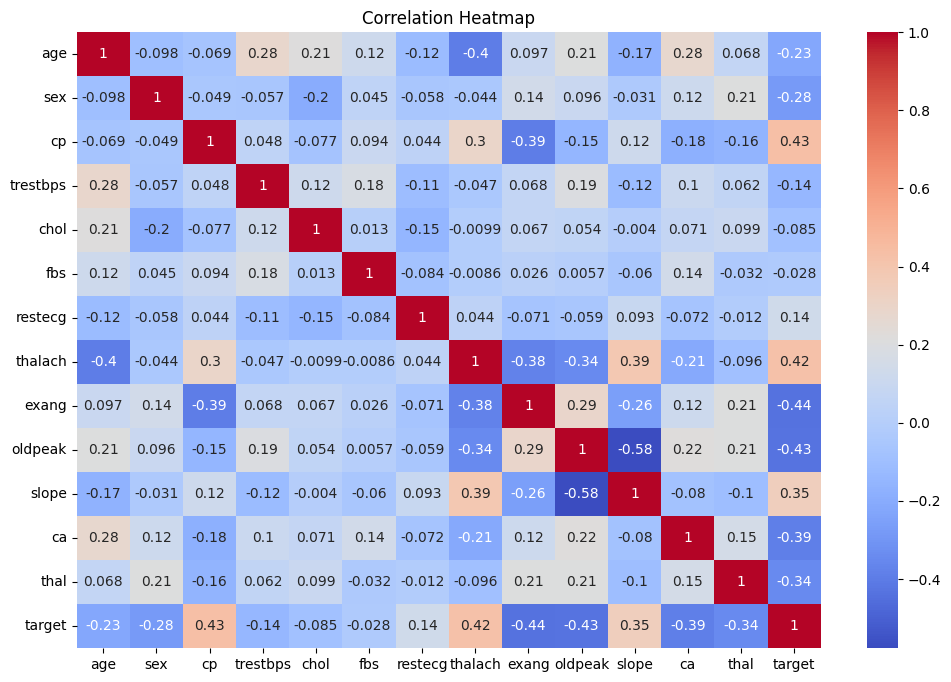

In [236]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

# Feature Selection

In [237]:
X = df.drop('target', axis=1)
y = df['target']

# **Train Test Split**

In [238]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Feature Scaling**

In [239]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model**

**Logistic Regression**

In [240]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)

Accuracy: 0.8524590163934426


**Decision Tree**

In [241]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_accuracy)

Accuracy: 0.7540983606557377


**Random  Forest**

In [242]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)

Accuracy: 0.8360655737704918


# Compare Models

In [243]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.852459
1,Decision Tree,0.754098
2,Random Forest,0.836066


# **Accuracy Visualization**

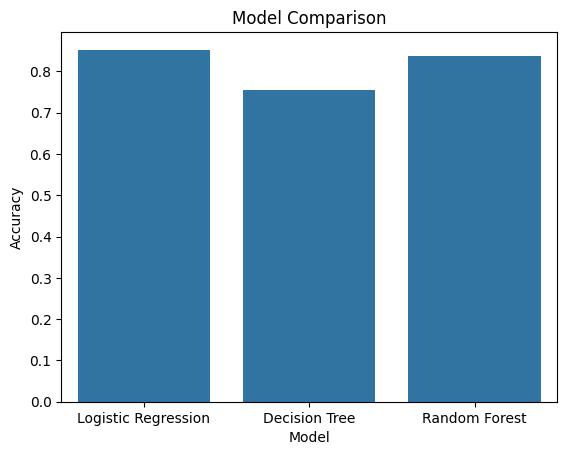

In [244]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")
plt.savefig("model_comparison.png")
plt.show()

# **Confusion Matrix**

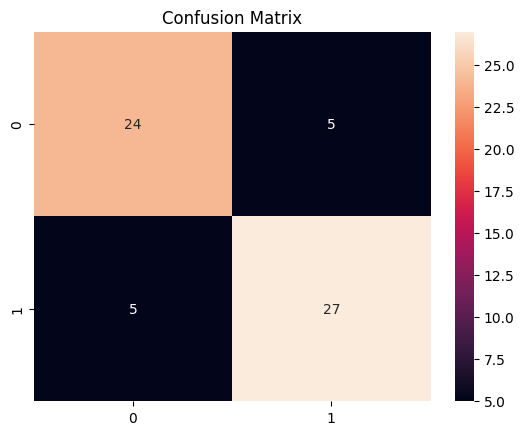

In [245]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# **Classification Report**

In [246]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



# **Conclusion**

"""
Conclusion:

1. Dataset contains 303 patient records.
2. EDA performed successfully.
3. Logistic Regression, Decision Tree,
   and Random Forest were trained.
4. Random Forest achieved the best accuracy.
5. The model can help predict heart disease
   based on patient health attributes.
"""